# Medida de fluxo de múons com coincidência dupla


Se utilizando de dois detectores, nós podemos medir o fluxo de partículas ionizantes como os múons através da coincidência entre estes dois detectores, ou seja: Se ambos tiverem sinal dentro de uma curta pequena janela de tempo.

Como queremos medir o fluxo total, nos interessa detectar partículas vindas de todas direções e com todos ângulos, então utilizaremos a coincidência entre duas RPCs diretamente sobrepostas, como na imagem abaixo:


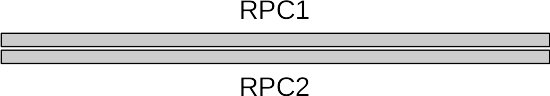

Para reduzir erros sistemáticos, <b>trataremos cada RPC como um detector contíguo de 1.824 m² de área sensível</b>. Uma coincidência será detectada sempre que <b>ambas</b> RPCs tiverem sinal em <b>uma ou mais pads </b> simultaneamente, sem discriminar em quais ou quantas.

Ao medir um número de coincidências (N) por um certo intervalo de tempo (T), nós obtemos uma <b>taxa de coincidências bruta $\big(\frac{N}{T}\big)$</b>. Se desprezado o erro de T, o único erro associado a esta taxa vem da natureza aleatória dos eventos, pois nós medimos durante um tempo finito, durante o qual o número contado está sujeito a flutuações em relação ao valor esperado . Sendo $\big(\frac{N}{T}\big)$</b> a taxa de coincidências brutas, seu erro será de $\Big(\frac{\sqrt{N}}{T}\Big)$


## Exercício 1: 

<b>Em uma aquisição neste setup, foram detectadas 10 milhões de coincidências em 46871 s. Despreze o erro do tempo, e calcule a taxa de coincidências bruta e seu erro </b>


In [14]:
from numpy import sqrt

coinc_bruta=10000000.0/46871.0
erro_bruta=sqrt(coinc_bruta)
print(coinc_bruta,erro_bruta)

213.35153933135626 14.606558093245523


O próximo passo agora é reduzir desta taxa bruta as coincidências falsas.

Apesar de que a janela de tempo para as coincidências é de <b>75 $\pm$ 5 ns</b>, ainda há uma taxa não desprezível de coincidência entre ruído de ambas RPCs.

Para poder deduzir as coincidências falsas, é preciso saber a <b>taxa de fundo</b> das RPCs, que representa a taxa com a qual cada RPC detecta algum sinal <b> independentemente de coincidência</b>. As taxas de fundo para nosso setup estão resumidas na tabela abaixo:


|rpc   |  taxa  |
|-|-|
|1| 26400 $\pm$ 300 Hz| 
|2| 5430 $\pm$ 50 Hz|

A grande maior parte destas taxas é <b> ruído aleatório e não passagem de partículas</b>. Como referência, mesmo se a eficiência das RPCs fosse 100%, haveriam menos de 300 Hz de eventos na RPC inteira, cerca de 4% do total da taxa de fundo da RPC menos ruidosa. 

Com esses valores, podemos calcular a taxa de coincidências falsas multiplicando as taxas de fundo pela janela de tempo e obtendo:

|combinação   |  taxa  |
|-|-|
|1 e 2| 10.75 $\pm$ 0.73 Hz| 


## Exercício 2:

<b>Reduza da taxa bruta obtida anteriormente a taxa de coincidências falsas, propagando os erros</b>


In [15]:
coinc_vdd=coinc_bruta-10.75
erro_vdd=sqrt(erro_bruta**2.0+0.73**2.0)
print(coinc_vdd,erro_vdd)


202.60153933135626 14.624788522619953


Agora, para estimar a taxa de múons cruzando ambas RPCs, precisamos compensar a eficiência eletrônica de ambas, dividindo a taxa de coincidências verdadeiras por ambas eficiências.

A eficiência dessas duas RPCs, que já foi calculada anteriormente, é de:

|RPC|eficiência|
|-|-|
|1|0.804 $\pm$ 0.007|
|2|0.938 $\pm$ 0.05|


## Exercício 3:

<b>Compense a taxa de coincidências verdadeiras pelas eficiências para encontrar a taxa de múons cruzando ambas RPCs</b>
    
    


In [16]:
coinc_tot=coinc_vdd/(0.804*0.938)
erro_tot=coinc_tot*sqrt((erro_vdd/coinc_vdd)**2.0 + (0.007/0.804)**2.0 + (0.05/0.938)**2.0)
print(coinc_tot,erro_tot)

268.64814961885173 24.219918822539945


Agora, antes de dividir essa taxa pela área para encontrar o fluxo, falta só uma coisa: compensar a <b>aceptância geométrica</b>, que reflete o fato de que nem todo múon cruzando a área de uma das RPCs cruza também a outra, como múons muito horizontais e/ou atravessando próximos da borda. A aceptância geométrica do nosso setup é de <b>0.9765</b>, então a última correção consiste em dividir o resultado por este número, antes de dividir pela área sensível para encontrar o fluxo final. 

Ou seja, a fórmula para o fluxo final é:

$\Large{\phi = \frac{Taxa\_Coinc\_bruta - Taxa\_Coinc\_falsas}{Área \cdot eff_{1} \cdot eff_{2}\cdot Acceptância}}$


## Exercício 4:

<b>Calcule o fluxo final de seu erro</b>



In [17]:
fluxo_tot=coinc_tot/(0.9765*1.824)
erro_fluxo=erro_tot/(0.9765*1.824)
print(fluxo_tot,erro_fluxo)


150.8296669197926 13.598017682276899
